# Wyżarzanie równoległe

Pseudokod

```julia
Initialize σ ← random {-1, 1}  # Inicjalizacja spinów
Initialize x ← [0]  # Pośrednia reprezentacja spinów
Initialize m ← [0]  # Initializacja momentum
Initialize K_max   # Liczba kroków wyżarzania
η ← step_size # Określenie kroku gradientu
λ  # Ustawienie początkowego współczynnika λ

for k ∈ 0:K_max -1

```

In [1]:
# Implementacja Algorytmu
import numpy as np
from typing import Optional
from funkcje_pomocnicze import calculate_energy


def calculate_gradient(J: np.ndarray, h: np.ndarray, x: np.ndarray, state: np.ndarray, lambda_t: float) -> np.ndarray:
    return -1 * state @ J - h + lambda_t * x


def parrarel_annealing(J, h, step_size: float, lambda_t_max: float, num_steps: int, 
                       schedule: Optional[np.ndarray] = None, schedule_endpoint: Optional[float] = 0):
    n = len(h)
    x = np.zeros(n)  # stan podstawowy dla H_innit = sum(x**2)
    momentum = np.zeros(n)
    state = np.random.choice([-1, 1], size=n) # losowy stan początkowy

    if schedule is None:
        schedule = np.linspace(lambda_t_max, schedule_endpoint, num=num_steps)

    for k in range(num_steps):
        lambda_t = schedule[k]
        gradient = calculate_gradient(J, h, x, state, lambda_t)
        momentum = (1 - step_size) * momentum - step_size * gradient
        momentum = np.clip(momentum, -1, 1)
        x += momentum
        x = np.clip(x, -1, 1)
        state = np.sign(x)

    return state, calculate_energy(J, h, state)



    


In [3]:

# Testujemy algorytm na instancji z 216 spinów i z geometryczną strukturą podobną do pegasus QPU

import os
import numpy as np

from funkcje_pomocnicze import read_instance, test_pegasus


J, h = read_instance(test_pegasus.path, convention="minus_half")


state, energy = parrarel_annealing(J, h, step_size=0.01, lambda_t_max=10, num_steps=1000)


print(f"Otrzymana energia: {energy}\n")
print(f"Stan podstawowy: {test_pegasus.best_energy}")



Otrzymana energia: -467.0

Stan podstawowy: -469.0


Przez to że algorytm sam w sobie jest stochastyczny nie mamy gwarancji że w trakcie jednego wywołania otrzymamy najlepszy możliwy wynik. Jedym z rozwiązań tego problemu jest wywołąnie algorytmu wielokrotnie z różnych punktów startowych. Wtedy śledzimy wiele "trajektorii" jednocześnie i na końcu możemy wybrać najlepszy wynik.

100%|██████████| 32/32 [00:00<00:00, 41.73it/s]


Otrzymana energia: -469.0
Stan podstawowy: -469.0


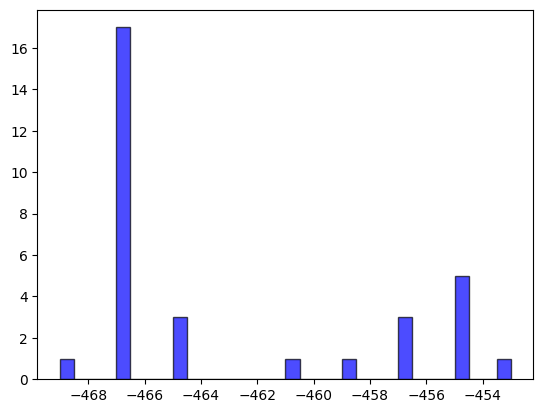

In [19]:
# Wiele trajektorii
import matplotlib.pyplot as plt
from tqdm import tqdm


num_trajectories = 2 ** 5
energies = []

for _ in tqdm(range(num_trajectories)):
    state, energy = parrarel_annealing(J, h, step_size=0.01, lambda_t_max=10, num_steps=1000)
    energies.append(energy)

print(f"Otrzymana energia: {min(energies)}")
print(f"Stan podstawowy: {test_pegasus.best_energy}")

plt.hist(energies, bins=num_trajectories, color='blue', edgecolor='black', alpha=0.7)
plt.show()
# TODO: Ładniejszy wykres

Dla większych ibstabcji takie wielokrotne liczenie może być bardzo kosztowne. Na szczęśie istnieje sposób by w efektywny sposób śledzić wiele trajektorii jednocześnie. Możemy jednocześnie działać na wielu stanach jeżeli ułożymy je w macierz. Niech $\sigma$ będzie stanem, wtedy mając $M$ trajektorii:

$$
\sigma = \begin{bmatrix}
\vert & \vert & \cdots & \vert \\
\sigma_1 & \sigma_2 & \cdots & \sigma_M \\
\vert & \vert & \cdots & \vert
\end{bmatrix}
$$

Wybór czy trzymamy stany w kolumnach czy w wierszach jest poniekąt arbitralny.

W podobny sposób możemy trzymać $x$ i momentum. Nie zmieni to nic fundamentalnego w algorytmie.

In [ ]:
# Wyżarzanie równoległe wiele trajektorii
# To jest w sumie powinnop się nazywać parrarel annealing
from funkcje_pomocnicze import calculate_energy_matrix


def calculate_gradient_matrix(J: np.ndarray, h: np.ndarray, x: np.ndarray, state: np.ndarray, lambda_t: float) -> np.ndarray:
    n = len(h)
    # używamy brodcastingu który jest wykonywany automatycznie w bibliotece numpy
    return -1 * J @ state - h.reshape((n, 1)) + lambda_t * x


def parrarel_annealing_multiple_trajectores(J, h, step_size: float, lambda_t_max: float, num_steps: int, num_trajectories: int,
                       schedule: Optional[np.ndarray] = None, schedule_endpoint: Optional[float] = 0):
    n = len(h)
    x = np.zeros((n, num_trajectories))  # stan podstawowy dla H_innit = sum(x**2)
    momentum = np.zeros((n, num_trajectories))
    state = np.random.choice([-1, 1], size=(n, num_trajectories))  # losowy stan początkowy

    if schedule is None:
        schedule = np.linspace(lambda_t_max, schedule_endpoint, num=num_steps)

    for k in tqdm(range(num_steps), desc="wyżarzanie równoległe"):
        lambda_t = schedule[k]
        gradient = calculate_gradient_matrix(J, h, x, state, lambda_t)
        momentum = (1 - step_size) * momentum - step_size * gradient
        momentum = np.clip(momentum, -1, 1)
        x += momentum
        x = np.clip(x, -1, 1)
        state = np.sign(x)

    return state, calculate_energy_matrix(J, h, state)




wyżarzanie równoległe:   0%|          | 0/1000 [00:00<?, ?it/s]

wyżarzanie równoległe: 100%|██████████| 1000/1000 [00:00<00:00, 6663.38it/s]


Otrzymana energia: -469.0
Stan podstawowy: -469.0


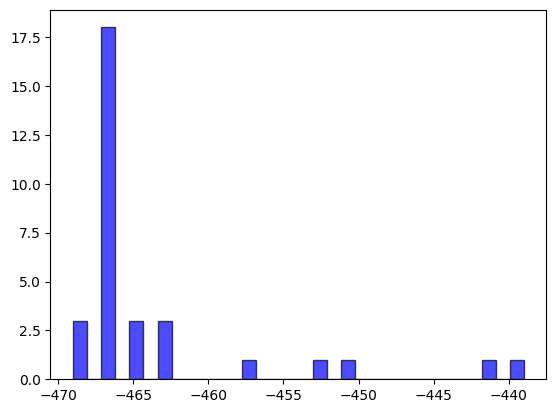

In [18]:
# Ten sam test dla 216 spinów
J, h = read_instance(test_pegasus.path, convention="minus_half")

states, energies = parrarel_annealing_multiple_trajectores(J, h, step_size=0.01, lambda_t_max=10, num_steps=1000, num_trajectories=32)

print(f"Otrzymana energia: {min(energies)}")
print(f"Stan podstawowy: {test_pegasus.best_energy}")


plt.hist(energies, bins=32, color='blue', edgecolor='black', alpha=0.7)
plt.show()

Spróbujemy rozwiązać instancje zubdowane na ponad 5 tysięcy spinach i o strukturze podobnej do QPU.

In [20]:
# Pełen pegaz

# E = -12772
# best found -12736 steps 10^4 trajectories 2^10 time approx 1.5h

from funkcje_pomocnicze import full_pegasus
J, h = read_instance(full_pegasus.path)

states, energies = parrarel_annealing_multiple_trajectores(J, h, step_size=0.01, lambda_t_max=10, num_steps=10000, num_trajectories=2**10)


print(f"Otrzymana energia: {min(energies)}")
print(f"Najlepsza znaleziona energia: {full_pegasus.best_energy}")

wyżarzanie równoległe:   1%|          | 122/10000 [00:35<48:04,  3.43it/s]


KeyboardInterrupt: 

Ten algorytm zaimplementowany na CPU jest kosztowny przy liczeniu dużych instancji. Jednakże możemy go znacząco przyspieszyc wykorzystując pararelizm incherentny dla GPU

# Bibliografia

* Jiang, M., Shan, K., He, C. *et al.* Efficient combinatorial optimization by quantum-inspired parallel annealing in analogue memristor crossbar. *Nat Commun* **14**, 5927 (2023). DOI: [10.1038/s41467-023-41647-2](https://doi.org/10.1038/s41467-023-41647-2)